<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Histogram**


Estimated time needed: **45** minutes


In this lab, you will focus on the visualization of data. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


In this lab, you will perform the following:


- Visualize the distribution of data using histograms.

- Visualize relationships between features.

- Explore data composition and comparisons.


## Demo: Working with database


#### Download the database file.


In [1]:
!wget -O survey-data.sqlite https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite

--2026-03-28 20:41:44--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
200 OKequest sent, awaiting response... 
Length: 211415040 (202M) [application/octet-stream]
Saving to: ‘survey-data.sqlite’

survey-data.sqlite  100%[===================>] 201.62M  46.7MB/s    in 4.4s    

2026-03-28 20:41:48 (46.1 MB/s) - ‘survey-data.sqlite’ saved [211415040/211415040]



#### Install the required libraries and import them


In [2]:
!pip install pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 160.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 173.1 MB/s eta 0:00:00


In [3]:
!pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 87.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 57.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 70.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 141.5 MB/s eta 0:00:00


In [4]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

#### Connect to the SQLite database


In [5]:
conn = sqlite3.connect('survey-data.sqlite')

## Demo: Basic SQL queries

**Demo 1: Count the number of rows in the table**


In [6]:
QUERY = "SELECT COUNT(*) FROM main"
df = pd.read_sql_query(QUERY, conn)
print(df)


   COUNT(*)
0     65437


**Demo 2: List all tables**


In [7]:
QUERY = """
SELECT name as Table_Name 
FROM sqlite_master 
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)


,Table_Name
0,main


**Demo 3: Group data by age**


In [9]:
QUERY = """
SELECT Age, COUNT(*) as count 
FROM main 
GROUP BY Age 
ORDER BY Age
"""

df_age = pd.read_sql_query(QUERY, conn)

age_mapping = {
    'Under 18 years old': 17,
    '18-24 years old': 21,
    '25-34 years old': 30,
    '35-44 years old': 40,
    '45-54 years old': 50,
    '55-64 years old': 60,
    '65 years or older': 70
}

df_age['AgeNumeric'] = df_age['Age'].map(age_mapping)

print(df_age)


                  Age  count  AgeNumeric
0     18-24 years old  14098        21.0
1     25-34 years old  23911        30.0
2     35-44 years old  14942        40.0
3     45-54 years old   6249        50.0
4     55-64 years old   2575        60.0
5   65 years or older    772        70.0
6   Prefer not to say    322         NaN
7  Under 18 years old   2568        17.0


## Hands-on Lab: Visualizing Data with Histograms


### 1. Visualizing the distribution of data (Histograms)


**1.1 Histogram of `CompTotal` (Total Compensation)**


Objective: Plot a histogram of `CompTotal` to visualize the distribution of respondents' total compensation.


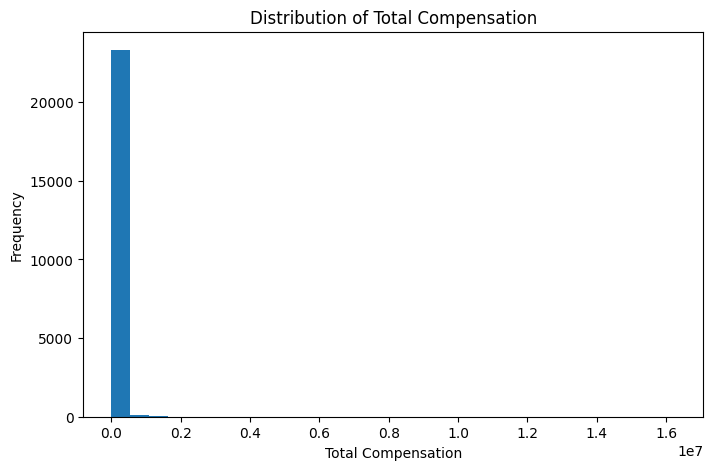

In [10]:
## Write your code here

# Query compensation data
QUERY = """
SELECT ConvertedCompYearly
FROM main;
"""
df_comp = pd.read_sql_query(QUERY, conn)

# Convert to numeric
df_comp['ConvertedCompYearly'] = pd.to_numeric(df_comp['ConvertedCompYearly'], errors='coerce')

# Drop missing values
df_comp = df_comp.dropna(subset=['ConvertedCompYearly'])

# Plot histogram
plt.figure(figsize=(8,5))
plt.hist(df_comp['ConvertedCompYearly'], bins=30)
plt.xlabel('Total Compensation')
plt.ylabel('Frequency')
plt.title('Distribution of Total Compensation')
plt.show()

**1.2 Histogram of YearsCodePro (Years of Professional Coding Experience)**


Objective: Plot a histogram of `YearsCodePro` to analyze the distribution of coding experience among respondents.


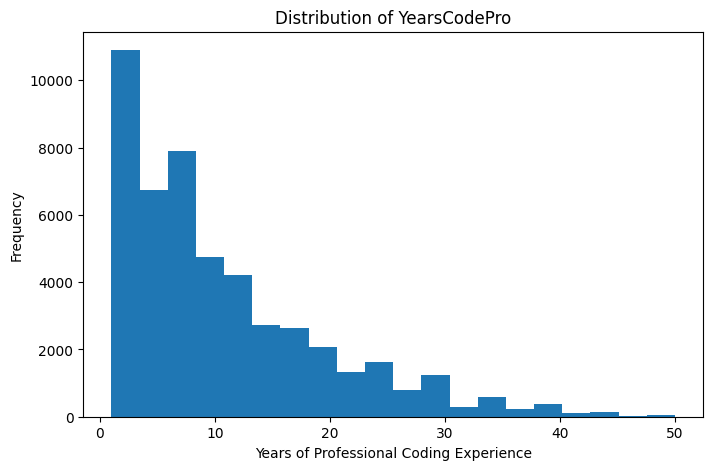

In [11]:
## Write your code here

# Query YearsCodePro
QUERY = """
SELECT YearsCodePro
FROM main;
"""
df_exp = pd.read_sql_query(QUERY, conn)

# Convert to numeric
df_exp['YearsCodePro'] = pd.to_numeric(df_exp['YearsCodePro'], errors='coerce')

# Drop missing values
df_exp = df_exp.dropna(subset=['YearsCodePro'])

# Plot histogram
plt.figure(figsize=(8,5))
plt.hist(df_exp['YearsCodePro'], bins=20)
plt.xlabel('Years of Professional Coding Experience')
plt.ylabel('Frequency')
plt.title('Distribution of YearsCodePro')
plt.show()

### 2. Visualizing Relationships in Data


**2.1 Histogram Comparison of `CompTotal` by `Age` Group**


Objective: Use histograms to compare the distribution of CompTotal across different Age groups.


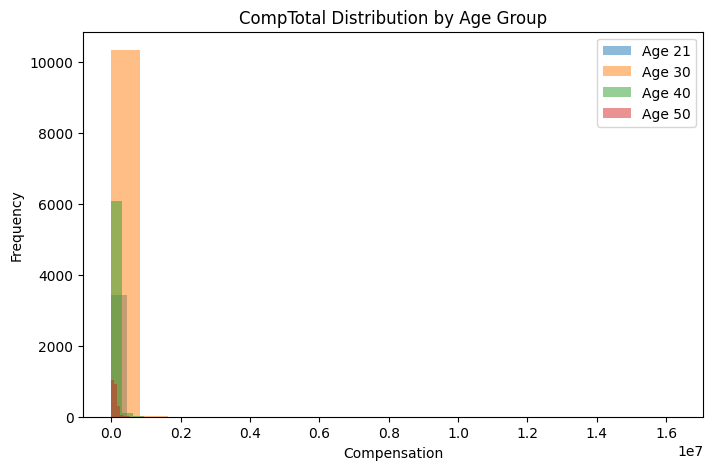

In [12]:
## Write your code here

# Query Age + Compensation
QUERY = """
SELECT Age, ConvertedCompYearly
FROM main;
"""
df_comp_age = pd.read_sql_query(QUERY, conn)

# Map Age
age_mapping = {
    'Under 18 years old': 17,
    '18-24 years old': 21,
    '25-34 years old': 30,
    '35-44 years old': 40,
    '45-54 years old': 50,
    '55-64 years old': 60,
    '65 years or older': 70
}
df_comp_age['AgeNumeric'] = df_comp_age['Age'].map(age_mapping)

# Convert compensation
df_comp_age['ConvertedCompYearly'] = pd.to_numeric(df_comp_age['ConvertedCompYearly'], errors='coerce')

# Drop missing
df_comp_age = df_comp_age.dropna(subset=['ConvertedCompYearly', 'AgeNumeric'])

# Plot histograms for a few age groups
plt.figure(figsize=(8,5))

for age in [21, 30, 40, 50]:  # selected age groups
    subset = df_comp_age[df_comp_age['AgeNumeric'] == age]
    plt.hist(subset['ConvertedCompYearly'], bins=20, alpha=0.5, label=f'Age {age}')

plt.xlabel('Compensation')
plt.ylabel('Frequency')
plt.title('CompTotal Distribution by Age Group')
plt.legend()
plt.show()

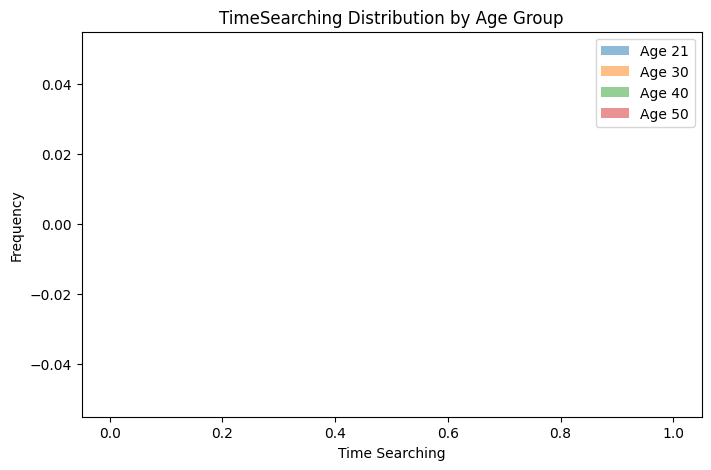

In [15]:
# Query data
QUERY = """
SELECT Age, TimeSearching
FROM main;
"""
df_time = pd.read_sql_query(QUERY, conn)

# Map Age
df_time['AgeNumeric'] = df_time['Age'].map(age_mapping)

# Convert TimeSearching to numeric
df_time['TimeSearching'] = pd.to_numeric(df_time['TimeSearching'], errors='coerce')

# Drop missing values
df_time = df_time.dropna(subset=['TimeSearching', 'AgeNumeric'])

# Plot (only if data exists)
plt.figure(figsize=(8,5))

for age in [21, 30, 40, 50]:
    subset = df_time[df_time['AgeNumeric'] == age]
    plt.hist(subset['TimeSearching'], bins=10, alpha=0.5, label=f'Age {age}')

plt.xlabel('Time Searching')
plt.ylabel('Frequency')
plt.title('TimeSearching Distribution by Age Group')
plt.legend()
plt.show()

**2.2 Histogram of TimeSearching for Different Age Groups**


Objective: Use histograms to explore the distribution of `TimeSearching` (time spent searching for information) for respondents across different age groups.


In [18]:
## Write your code here
QUERY = """
SELECT Age, TimeSearching
FROM main;
"""
df_time = pd.read_sql_query(QUERY, conn)

# Map Age
age_mapping = {
    'Under 18 years old': 17,
    '18-24 years old': 21,
    '25-34 years old': 30,
    '35-44 years old': 40,
    '45-54 years old': 50,
    '55-64 years old': 60,
    '65 years or older': 70
}
df_time['AgeNumeric'] = df_time['Age'].map(age_mapping)

# Convert TimeSearching
df_time['TimeSearching'] = pd.to_numeric(df_time['TimeSearching'], errors='coerce')

# Drop missing values
df_time = df_time.dropna(subset=['TimeSearching', 'AgeNumeric'])

# Plot only if data exists
if not df_time.empty:
    plt.figure(figsize=(8,5))
    for age in [21, 30, 40, 50]:
        subset = df_time[df_time['AgeNumeric'] == age]
        plt.hist(subset['TimeSearching'], bins=10, alpha=0.5, label=f'Age {age}')

    plt.xlabel('Time Searching')
    plt.ylabel('Frequency')
    plt.title('TimeSearching Distribution by Age Group')
    plt.legend()
    plt.show()
else:
    print("No valid TimeSearching data available.")

No valid TimeSearching data available.


### 3. Visualizing the Composition of Data


**3.1 Histogram of Most Desired Databases (`DatabaseWantToWorkWith`)**


Objective: Visualize the most desired databases for future learning using a histogram of the top 5 databases.


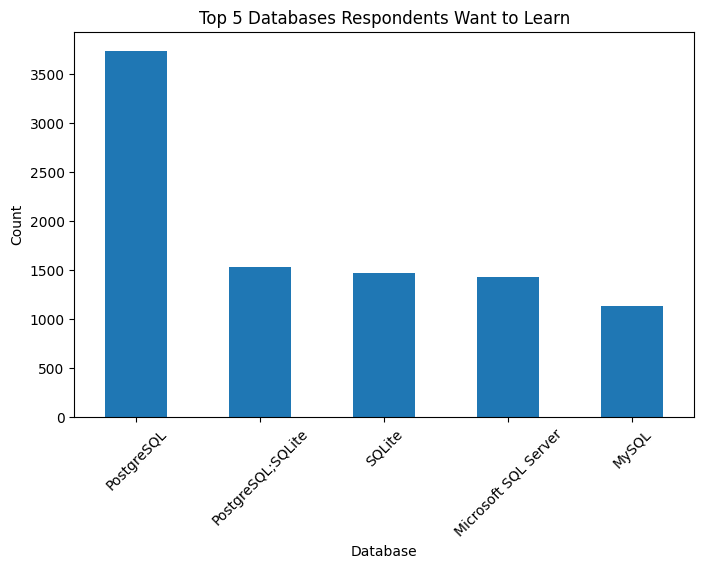

In [19]:
## Write your code here

QUERY = """
SELECT DatabaseWantToWorkWith
FROM main;
"""
df_db = pd.read_sql_query(QUERY, conn)

# Get top 5 databases
top5 = df_db['DatabaseWantToWorkWith'].value_counts().nlargest(5)

# Plot histogram-like bar chart
plt.figure(figsize=(8,5))
top5.plot(kind='bar')
plt.xlabel('Database')
plt.ylabel('Count')
plt.title('Top 5 Databases Respondents Want to Learn')
plt.xticks(rotation=45)
plt.show()

**3.2 Histogram of Preferred Work Locations (`RemoteWork`)**


Objective: Use a histogram to explore the distribution of preferred work arrangements (`remote work`).


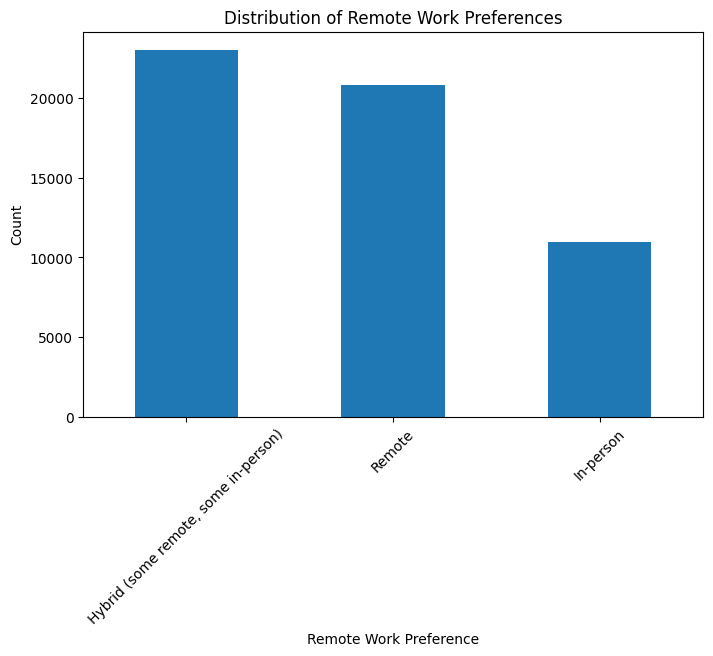

In [20]:
## Write your code here

QUERY = """
SELECT RemoteWork
FROM main;
"""
df_remote = pd.read_sql_query(QUERY, conn)

# Count categories
remote_counts = df_remote['RemoteWork'].value_counts()

# Plot
plt.figure(figsize=(8,5))
remote_counts.plot(kind='bar')
plt.xlabel('Remote Work Preference')
plt.ylabel('Count')
plt.title('Distribution of Remote Work Preferences')
plt.xticks(rotation=45)
plt.show()

### 4. Visualizing Comparison of Data


**4.1 Histogram of Median CompTotal for Ages 45 to 60**


Objective: Plot the histogram for `CompTotal` within the age group 45 to 60 to analyze compensation distribution among mid-career respondents.


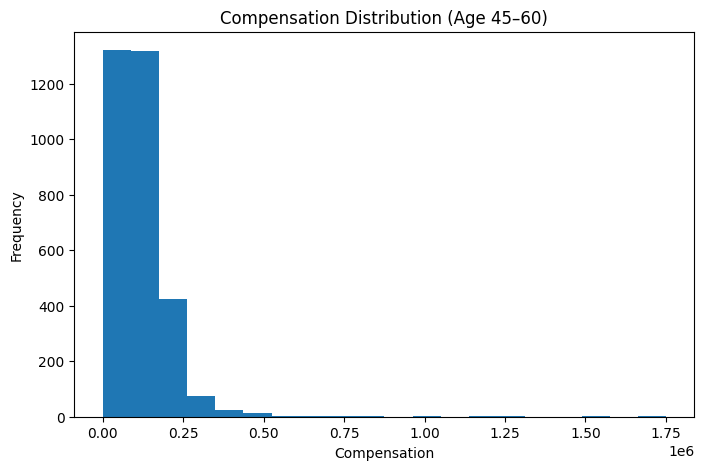

In [21]:
## Write your code here

QUERY = """
SELECT Age, ConvertedCompYearly
FROM main;
"""
df_comp = pd.read_sql_query(QUERY, conn)

# Map Age
df_comp['AgeNumeric'] = df_comp['Age'].map(age_mapping)

# Filter ages 45–60
df_comp = df_comp[(df_comp['AgeNumeric'] >= 45) & (df_comp['AgeNumeric'] <= 60)]

# Convert to numeric
df_comp['ConvertedCompYearly'] = pd.to_numeric(df_comp['ConvertedCompYearly'], errors='coerce')

# Drop missing
df_comp = df_comp.dropna(subset=['ConvertedCompYearly'])

# Plot histogram
plt.figure(figsize=(8,5))
plt.hist(df_comp['ConvertedCompYearly'], bins=20)
plt.xlabel('Compensation')
plt.ylabel('Frequency')
plt.title('Compensation Distribution (Age 45–60)')
plt.show()

**4.2 Histogram of Job Satisfaction (`JobSat`) by YearsCodePro**


Objective: Plot the histogram for `JobSat` scores based on respondents' years of professional coding experience.


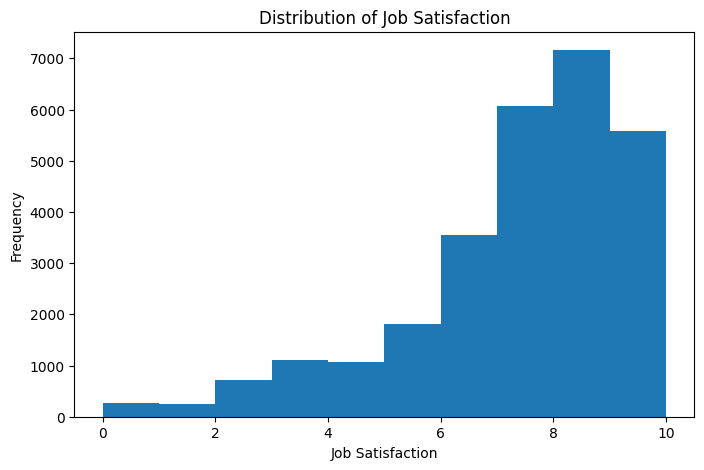

In [23]:
## Write your code here

QUERY = """
SELECT YearsCodePro, JobSat
FROM main;
"""
df_job = pd.read_sql_query(QUERY, conn)

# Convert to numeric
df_job['YearsCodePro'] = pd.to_numeric(df_job['YearsCodePro'], errors='coerce')
df_job['JobSat'] = pd.to_numeric(df_job['JobSat'], errors='coerce')

# Drop missing
df_job = df_job.dropna(subset=['YearsCodePro', 'JobSat'])

# Plot histogram of Job Satisfaction
plt.figure(figsize=(8,5))
plt.hist(df_job['JobSat'], bins=10)
plt.xlabel('Job Satisfaction')
plt.ylabel('Frequency')
plt.title('Distribution of Job Satisfaction')
plt.show()

### Final step: Close the database connection


Once you've completed the lab, make sure to close the connection to the SQLite database:



In [24]:
conn.close()

### Summary


In this lab, you used histograms to visualize various aspects of the dataset, focusing on:

- Distribution of compensation, coding experience, and work hours.

- Relationships in compensation across age groups and work status.

- Composition of data by desired databases and work environments.

- Comparisons of job satisfaction across years of experience.

Histograms helped reveal patterns and distributions in the data, enhancing your understanding of developer demographics and preferences.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
